# Task 1: Data Manipulation and Cleaning

### Task 1: Data Manipulation and Cleaning

#### Dataset use- https://github.com/gurmindero7/test_datasets/blob/main/employee_data.csv

In [70]:
# Importing important libraries and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# Importing dataset required
df = pd.read_csv("../datasets/employee_data.csv")

In [72]:
df.head()

,EmployeeID,Name,Department,Salary,JoiningDate,Status
0,7970,NaN,Operations,44168.0,2023-04-16,Terminated
1,1752,Shannon Franco,HR,80140.0,2016-08-22,Terminated
2,8478,NaN,HR,144316.0,2023-11-04,Terminated
3,5157,Barbara Alvarez,Operations,35075.0,2023-04-22,NaN
4,1816,Adam Cobb,Sales,142537.0,2016-05-12,Active


##### Data Cleaning:

In [73]:
# Remove any duplicate entries.
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [74]:
df.isna().sum()

EmployeeID      0
Name           50
Department     50
Salary         50
JoiningDate    50
Status         50
dtype: int64

In [75]:
# Handle missing values 
df.dropna(inplace=True)

In [76]:
df.isna().sum()

EmployeeID     0
Name           0
Department     0
Salary         0
JoiningDate    0
Status         0
dtype: int64

In [77]:

df['JoiningDate']

1      2016-08-22
4      2016-05-12
6      2023-06-14
7      2016-03-29
8      2018-08-04
          ...    
487    2023-06-13
488    2024-01-11
489    2016-04-01
492    2023-01-04
496    2022-09-23
Name: JoiningDate, Length: 293, dtype: object

In [78]:
print(df['JoiningDate'].dtype)

object


In [79]:
# Convert the JoiningDate column to a proper datetime format.
df['JoiningDate']=pd.to_datetime(df['JoiningDate'])

In [80]:
print(df['JoiningDate'].dtype)

datetime64[ns]


In [81]:
# Filter out employees who are no longer working (where Status is 'Resigned').
df[df['Status']=='Resigned']

,EmployeeID,Name,Department,Salary,JoiningDate,Status
10,4786,Loretta Espinoza,Operations,75830.0,2014-12-24,Resigned
12,4245,Jamie Aguilar,Finance,137549.0,2015-06-26,Resigned
14,7189,Andrew Zimmerman,Finance,144206.0,2015-09-17,Resigned
15,6554,George Jenkins,Marketing,59831.0,2015-01-13,Resigned
18,7627,Elizabeth Owens,HR,116511.0,2023-11-03,Resigned
...,...,...,...,...,...,...
465,4320,Austin Smith,Finance,90910.0,2020-05-22,Resigned
480,3147,Susan Burke,Finance,63862.0,2015-01-09,Resigned
482,4816,Bryan Cox,Finance,66655.0,2020-08-30,Resigned
483,6198,Thomas Nunez,Operations,145385.0,2017-09-20,Resigned


In [82]:
# Create a new column YearsOfService = CurrentYear(Take this as 2025) - JoiningDate.
df['YearOfService']=2025-df['JoiningDate'].dt.year

In [83]:
df['YearOfService']

1      9
4      9
6      2
7      9
8      7
      ..
487    2
488    1
489    9
492    2
496    3
Name: YearOfService, Length: 293, dtype: int32

##### Analysis:

In [84]:
# List all employees who joined after the year 2020.
df[df['JoiningDate'].dt.year>2020]

,EmployeeID,Name,Department,Salary,JoiningDate,Status,YearOfService
6,6247,Allison Salas,Engineering,59154.0,2023-06-14,On Leave,2
18,7627,Elizabeth Owens,HR,116511.0,2023-11-03,Resigned,2
19,9152,Whitney Curtis,Engineering,55313.0,2021-10-12,Resigned,4
25,6853,Steve Martin,Engineering,131361.0,2022-08-12,On Leave,3
44,6938,Thomas Kelly,HR,108193.0,2021-12-26,On Leave,4
...,...,...,...,...,...,...,...
481,9281,Edward Harvey,Marketing,74608.0,2021-11-13,Terminated,4
487,1586,Brian Kim,Engineering,66211.0,2023-06-13,Active,2
488,3772,Jonathan Haley,Marketing,102848.0,2024-01-11,Active,1
492,7210,Phillip Riley,Sales,41221.0,2023-01-04,Active,2


In [85]:
# Find the average salary of employees in each department.
df.groupby('Department')['Salary'].mean()

Department
Engineering    99588.586207
Finance        89270.709091
HR             84595.892857
Marketing      87002.975610
Operations     95357.350000
Sales          91920.000000
Name: Salary, dtype: float64

## Task 2: Data Visualization 

In [86]:
# Load the dataset into a Pandas DataFrame.
df=pd.read_csv('../datasets/CAR DETAILS.csv')

##### Understanding dataset

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [88]:
df.duplicated().sum()

np.int64(763)

In [89]:
df.drop_duplicates(inplace=True)

In [90]:
df.duplicated().sum()

np.int64(0)

In [91]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


##### Create at least four meaningful visualizations using Matplotlib or seaborn to understand the data better.

<Axes: >

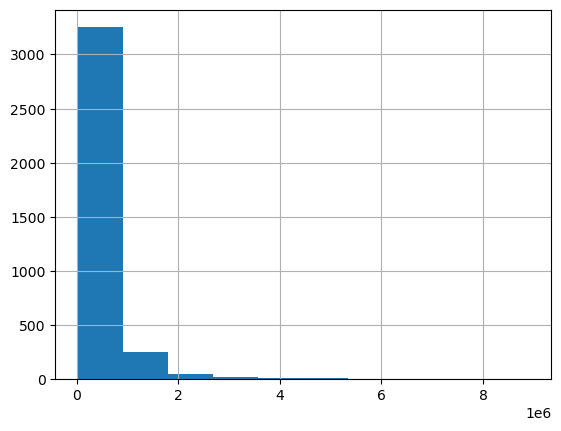

In [92]:
# Histogram for selling_price column
df['selling_price'].hist()

<Axes: xlabel='fuel', ylabel='count'>

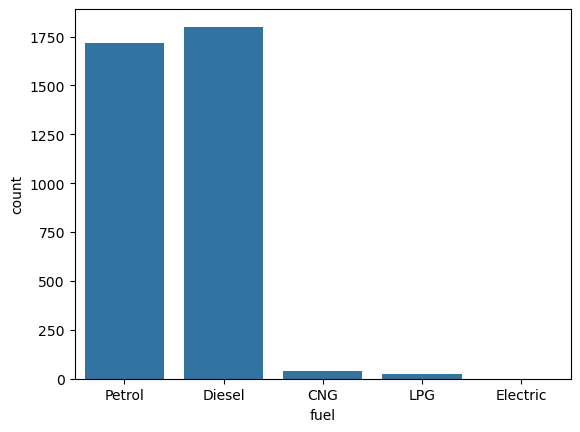

In [93]:
# Visualizing fuel column of each category
sns.countplot(x='fuel',data=df)

<Axes: xlabel='seller_type', ylabel='count'>

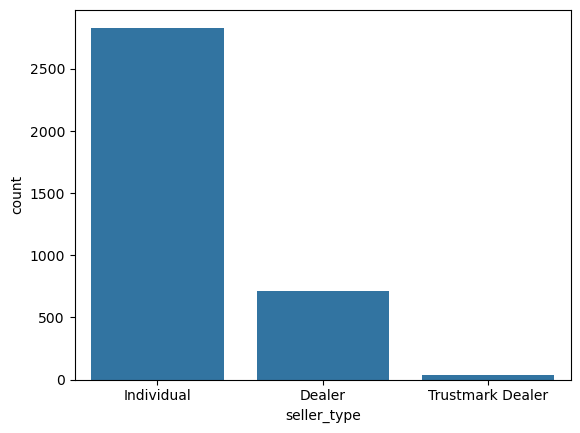

In [94]:
# Graph for visualizing the count of seller type of each category
sns.countplot(x='seller_type',data=df)

In [95]:
df.drop(columns='name',inplace=True)

In [96]:
numeric_feature=[feature for feature in df.columns if df[feature].dtype != 'O']

In [97]:
numeric_feature

['year', 'selling_price', 'km_driven']

##### Include one correlation heatmap of all numerical variables in the dataset.

<Axes: >

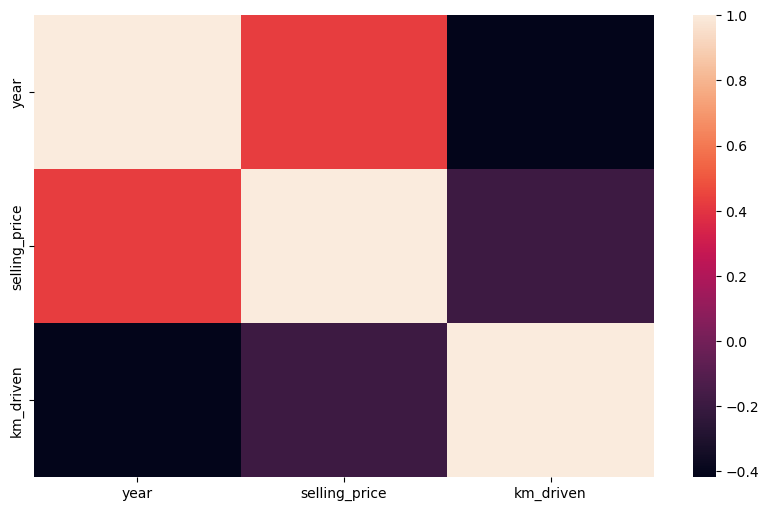

In [98]:
# Correlation graph - heatmap for numerical features of dataset
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_feature].corr())